# Notebook 4 — Simple ML: Can We Predict Anything?

**Goal:** Train simple ML models on the battle data to see if features are actually predictive. This is a baseline — the simplest thing that could work — before building anything sophisticated.

## Key Concepts

### Classification vs Regression
- **Classification** = predict a category. "Did the opponent fire? Yes/No." Output is a label.
- **Regression** = predict a number. "How much damage will be dealt?" Output is a continuous value.

### Train/Test Split
If you test a model on the same data you trained it on, it can just memorize the answers. That's **cheating** (called overfitting). Instead:
- **Training set (80%):** The model learns from this data
- **Test set (20%):** The model is tested on data it has **never seen**
- If accuracy is good on the test set → the model actually learned real patterns

### Decision Tree
A flowchart of yes/no questions: "Is distance > 300? → Yes → Is energy < 50? → Yes → predict: fired."
- **Pro:** Easy to understand and visualize
- **Con:** Can overfit (memorize noise instead of learning patterns)

### Random Forest
Build 100 different decision trees, each using a random subset of features and data. Take a **vote** — the majority wins.
- **Pro:** Much more robust than a single tree (the "wisdom of crowds")
- **Con:** Harder to interpret (100 trees instead of one)

### Feature Importance
After training a Random Forest, we can measure which features were most useful for making correct predictions. Features that appear near the top of many trees and make big improvements are "important."

### Confusion Matrix
A 2×2 table for classification results:

|  | Predicted: No | Predicted: Yes |
|--|---|---|
| **Actual: No** | True Negative ✓ | False Positive ✗ |
| **Actual: Yes** | False Negative ✗ | True Positive ✓ |

**Accuracy** = (correct predictions) / (total). But if the opponent fires only 5% of ticks, always predicting "no" gives 95% accuracy! So we also look at:
- **Precision** = of all "yes" predictions, how many were actually yes?
- **Recall** = of all actual "yes" cases, how many did we find?

In [1]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                              ConfusionMatrixDisplay, accuracy_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

CSV_ROOT = Path("../output/csv")

def load_all_csvs(filename):
    frames = []
    for csv_path in sorted(CSV_ROOT.rglob(filename)):
        robot_name = csv_path.parent.name
        df = pd.read_csv(csv_path)
        df['robot_name'] = robot_name
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

ticks = load_all_csvs("ticks.csv")
scores = load_all_csvs("scores.csv")

meta_cols = ['battle_id', 'round', 'tick', 'scan_available', 'robot_name']
feature_cols = [c for c in ticks.columns 
                if c not in meta_cols + ['opponent_fired', 'opponent_fire_power']
                and ticks[c].dtype in ['float64', 'int64']]
print(f"Loaded {len(ticks):,} ticks, {len(feature_cols)} predictor features")

Loaded 266,890 ticks, 22 predictor features


## Task 1: Predict Whether the Opponent Fired

This is a **binary classification** problem: given the game state (distance, velocities, energy, etc.), can we predict whether the opponent fired this tick?

This is directly useful for the robot — if we can predict firing, we can start dodging.

In [2]:
# --- Prepare data ---
# Only use scan ticks (opponent_fired is NaN when no scan)
scan_ticks = ticks[ticks['scan_available'] == 1].copy()

# Target: opponent_fired (0 or 1)
target = 'opponent_fired'
X = scan_ticks[feature_cols].copy()
y = scan_ticks[target].copy()

# Drop rows where target or any feature is NaN
valid = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid]
y = y.loc[valid].astype(int)

print(f"Dataset: {len(X):,} rows")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"Firing rate: {y.mean()*100:.1f}% of ticks have opponent_fired=1")

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,} rows, Test: {len(X_test):,} rows")

Dataset: 251,107 rows
Class balance: {0: 234040, 1: 17067}
Firing rate: 6.8% of ticks have opponent_fired=1

Train: 200,885 rows, Test: 50,222 rows


In [3]:
# --- Train models ---
models = {
    'Decision Tree (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Decision Tree (unlimited)': DecisionTreeClassifier(random_state=42),
    'Random Forest (100 trees)': RandomForestClassifier(n_estimators=100, max_depth=10, 
                                                         random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

results = {}
for name, model in models.items():
    # Scale features for logistic regression (trees don't need it, but it doesn't hurt)
    if 'Logistic' in name:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train)
        X_te = scaler.transform(X_test)
    else:
        X_tr, X_te = X_train.values, X_test.values
    
    model.fit(X_tr, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc = accuracy_score(y_test, model.predict(X_te))
    results[name] = {'train_accuracy': train_acc, 'test_accuracy': test_acc, 'model': model}
    print(f"{name:40s} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

# Flag overfitting
print("\n⚠ If train accuracy >> test accuracy, the model is OVERFITTING (memorizing instead of learning)")
for name, r in results.items():
    gap = r['train_accuracy'] - r['test_accuracy']
    if gap > 0.05:
        print(f"  {name}: gap = {gap:.3f} — OVERFITTING")

Decision Tree (depth=5)                  | Train: 0.9889 | Test: 0.9884
Decision Tree (unlimited)                | Train: 1.0000 | Test: 0.9928
Random Forest (100 trees)                | Train: 0.9915 | Test: 0.9888
Logistic Regression                      | Train: 0.9351 | Test: 0.9354

⚠ If train accuracy >> test accuracy, the model is OVERFITTING (memorizing instead of learning)


## Confusion Matrix & Classification Report

The confusion matrix shows exactly where the model succeeds and fails:
- **True Positive:** Model said "fired" and opponent actually fired ✓
- **True Negative:** Model said "not fired" and opponent didn't fire ✓
- **False Positive:** Model said "fired" but opponent didn't (false alarm) ✗
- **False Negative:** Model said "not fired" but opponent actually fired (missed detection) ✗

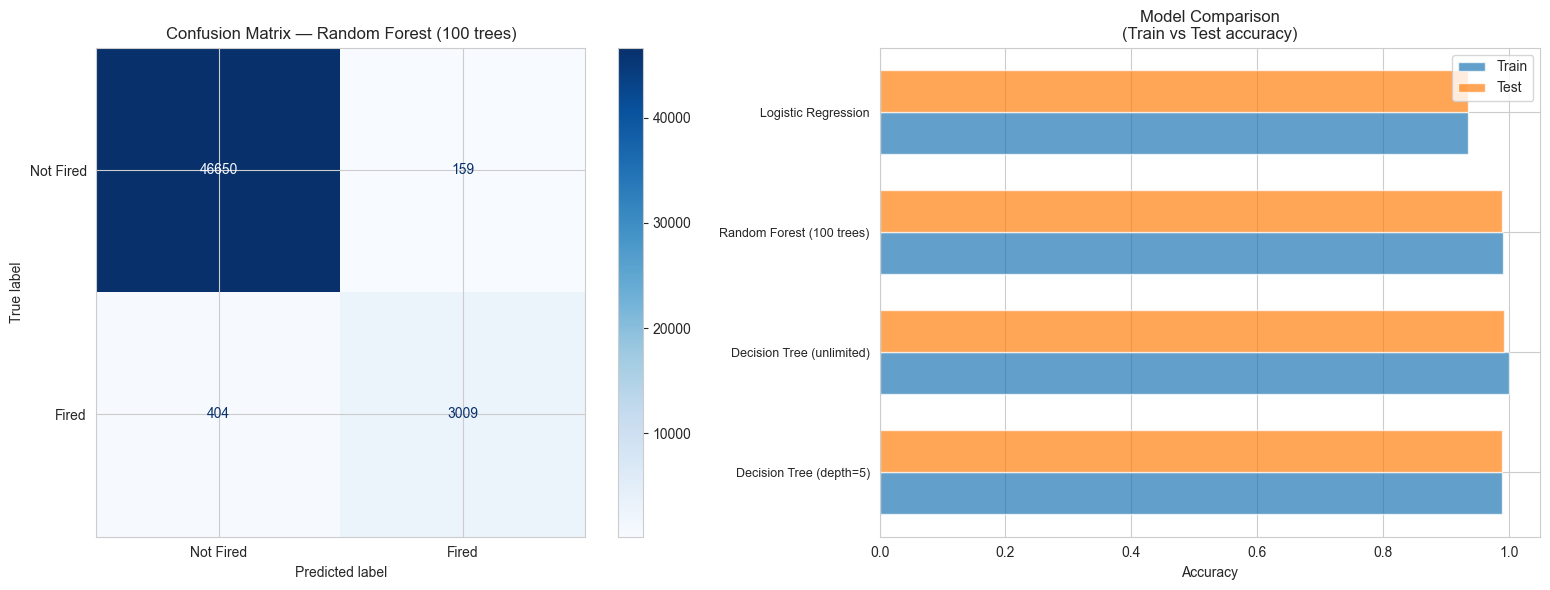


Classification Report — Random Forest (100 trees):
              precision    recall  f1-score   support

   Not Fired       0.99      1.00      0.99     46809
       Fired       0.95      0.88      0.91      3413

    accuracy                           0.99     50222
   macro avg       0.97      0.94      0.95     50222
weighted avg       0.99      0.99      0.99     50222



In [4]:
# --- Confusion matrix for best model (Random Forest) ---
best_name = 'Random Forest (100 trees)'
best_model = results[best_name]['model']
y_pred = best_model.predict(X_test.values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], 
                                         display_labels=['Not Fired', 'Fired'],
                                         cmap='Blues')
axes[0].set_title(f"Confusion Matrix — {best_name}")

# Accuracy comparison bar chart
model_names = list(results.keys())
test_accs = [results[n]['test_accuracy'] for n in model_names]
train_accs = [results[n]['train_accuracy'] for n in model_names]

x_pos = np.arange(len(model_names))
width = 0.35
axes[1].barh(x_pos - width/2, train_accs, width, label='Train', alpha=0.7)
axes[1].barh(x_pos + width/2, test_accs, width, label='Test', alpha=0.7)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(model_names, fontsize=9)
axes[1].set_xlabel("Accuracy")
axes[1].set_title("Model Comparison\n(Train vs Test accuracy)")
axes[1].legend()
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

# Classification report
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, y_pred, target_names=['Not Fired', 'Fired']))

## Feature Importance

Which features matter most for predicting opponent firing? The Random Forest tells us — features that frequently appear near the top of decision trees and make the biggest improvements are ranked highest.

This is one of the most valuable outputs of this entire notebook: it tells us where to focus our attention for building better features.

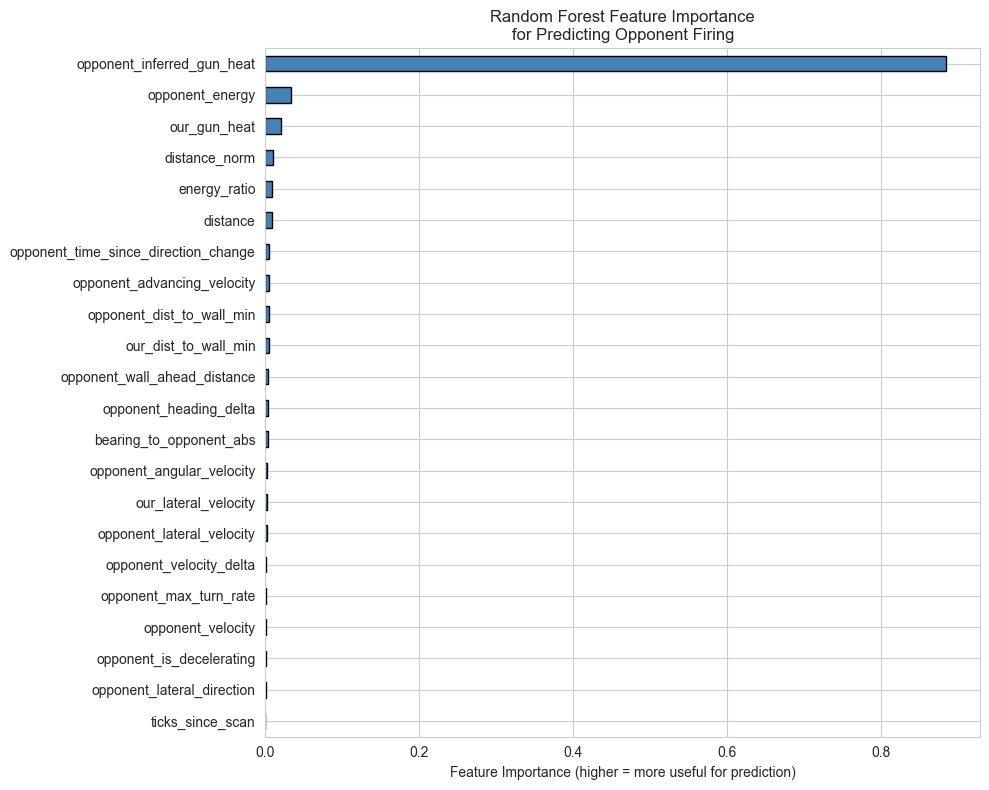


Top 5 most important features for predicting firing:
  opponent_inferred_gun_heat: 0.8845
  opponent_energy: 0.0326
  our_gun_heat: 0.0203
  distance_norm: 0.0100
  energy_ratio: 0.0089


In [5]:
# --- Feature importance from Random Forest ---
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel("Feature Importance (higher = more useful for prediction)")
ax.set_title("Random Forest Feature Importance\nfor Predicting Opponent Firing")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features for predicting firing:")
for feat, imp in importances.nlargest(5).items():
    print(f"  {feat}: {imp:.4f}")

## Learning Curves

Does more data help? A **learning curve** shows how accuracy changes as we increase the training set size.

- If both train and test accuracy are high → the model is learning well
- If train accuracy is high but test is low → overfitting (model memorizes instead of learning)
- If both are low → underfitting (model is too simple, or features aren't informative enough)
- If test accuracy is still climbing → more data would probably help

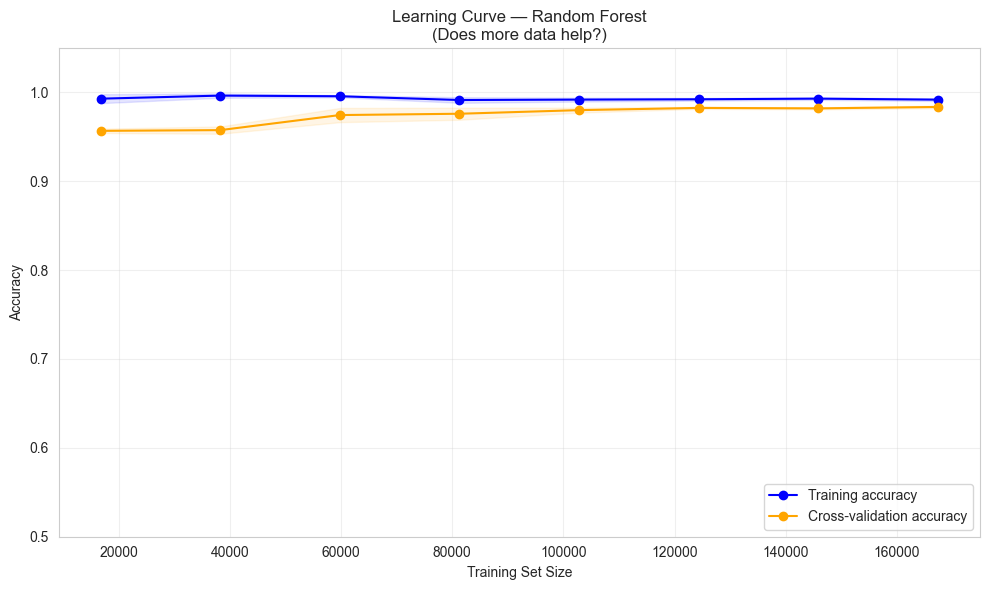

In [6]:
# --- Learning curves ---
fig, ax = plt.subplots(figsize=(10, 6))

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    X.values, y.values,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training accuracy')
ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation accuracy')

ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — Random Forest\n(Does more data help?)")
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2: Predict Net Damage from Scores

Using the scores.csv data, can we predict which robot wins a round (positive net_damage) from round-level statistics? This is a much smaller dataset (100 rows) so results will be noisier.

Scores dataset: 100 rows
Win rate (net_damage > 0): 50.0%

Random Forest accuracy on scores: 0.600
(Baseline: always predict majority class = 0.500)


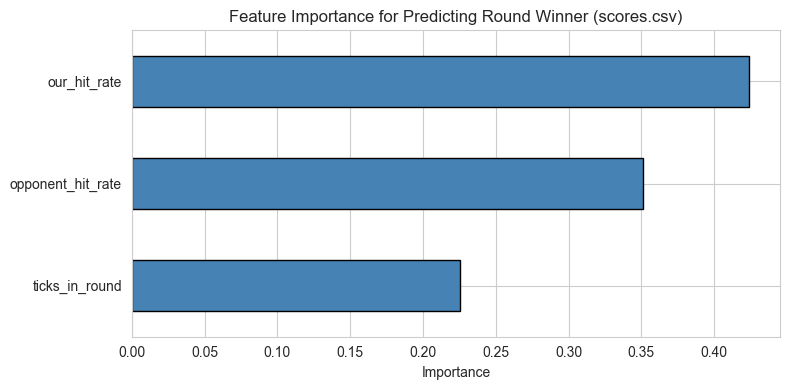

In [7]:
# --- Scores-based prediction ---
score_features = ['ticks_in_round', 'our_hit_rate', 'opponent_hit_rate']
score_features = [f for f in score_features if f in scores.columns]

if len(score_features) >= 2 and 'net_damage' in scores.columns:
    # Classify: did we win the round? (net_damage > 0)
    scores_clean = scores[score_features + ['net_damage']].dropna()
    X_scores = scores_clean[score_features]
    y_scores = (scores_clean['net_damage'] > 0).astype(int)
    
    print(f"Scores dataset: {len(X_scores)} rows")
    print(f"Win rate (net_damage > 0): {y_scores.mean()*100:.1f}%")
    
    if len(X_scores) >= 20:
        X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
            X_scores, y_scores, test_size=0.3, random_state=42
        )
        
        rf_scores = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
        rf_scores.fit(X_s_train, y_s_train)
        
        print(f"\nRandom Forest accuracy on scores: {rf_scores.score(X_s_test, y_s_test):.3f}")
        print(f"(Baseline: always predict majority class = {max(y_scores.mean(), 1-y_scores.mean()):.3f})")
        
        # Feature importance
        imp = pd.Series(rf_scores.feature_importances_, index=score_features).sort_values()
        fig, ax = plt.subplots(figsize=(8, 4))
        imp.plot.barh(ax=ax, color='steelblue', edgecolor='black')
        ax.set_title("Feature Importance for Predicting Round Winner (scores.csv)")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough score data for train/test split")
else:
    print(f"Available score columns: {list(scores.columns)}")

## Time-Series: Rolling Averages

Since ticks are sequential, let's treat features as **time series** within each round. A **rolling average** smooths out noise by averaging the last N ticks:

$$\text{rolling\_mean}(t) = \frac{1}{N} \sum_{i=t-N+1}^{t} x_i$$

This shows trends that are invisible in the noisy raw signal.

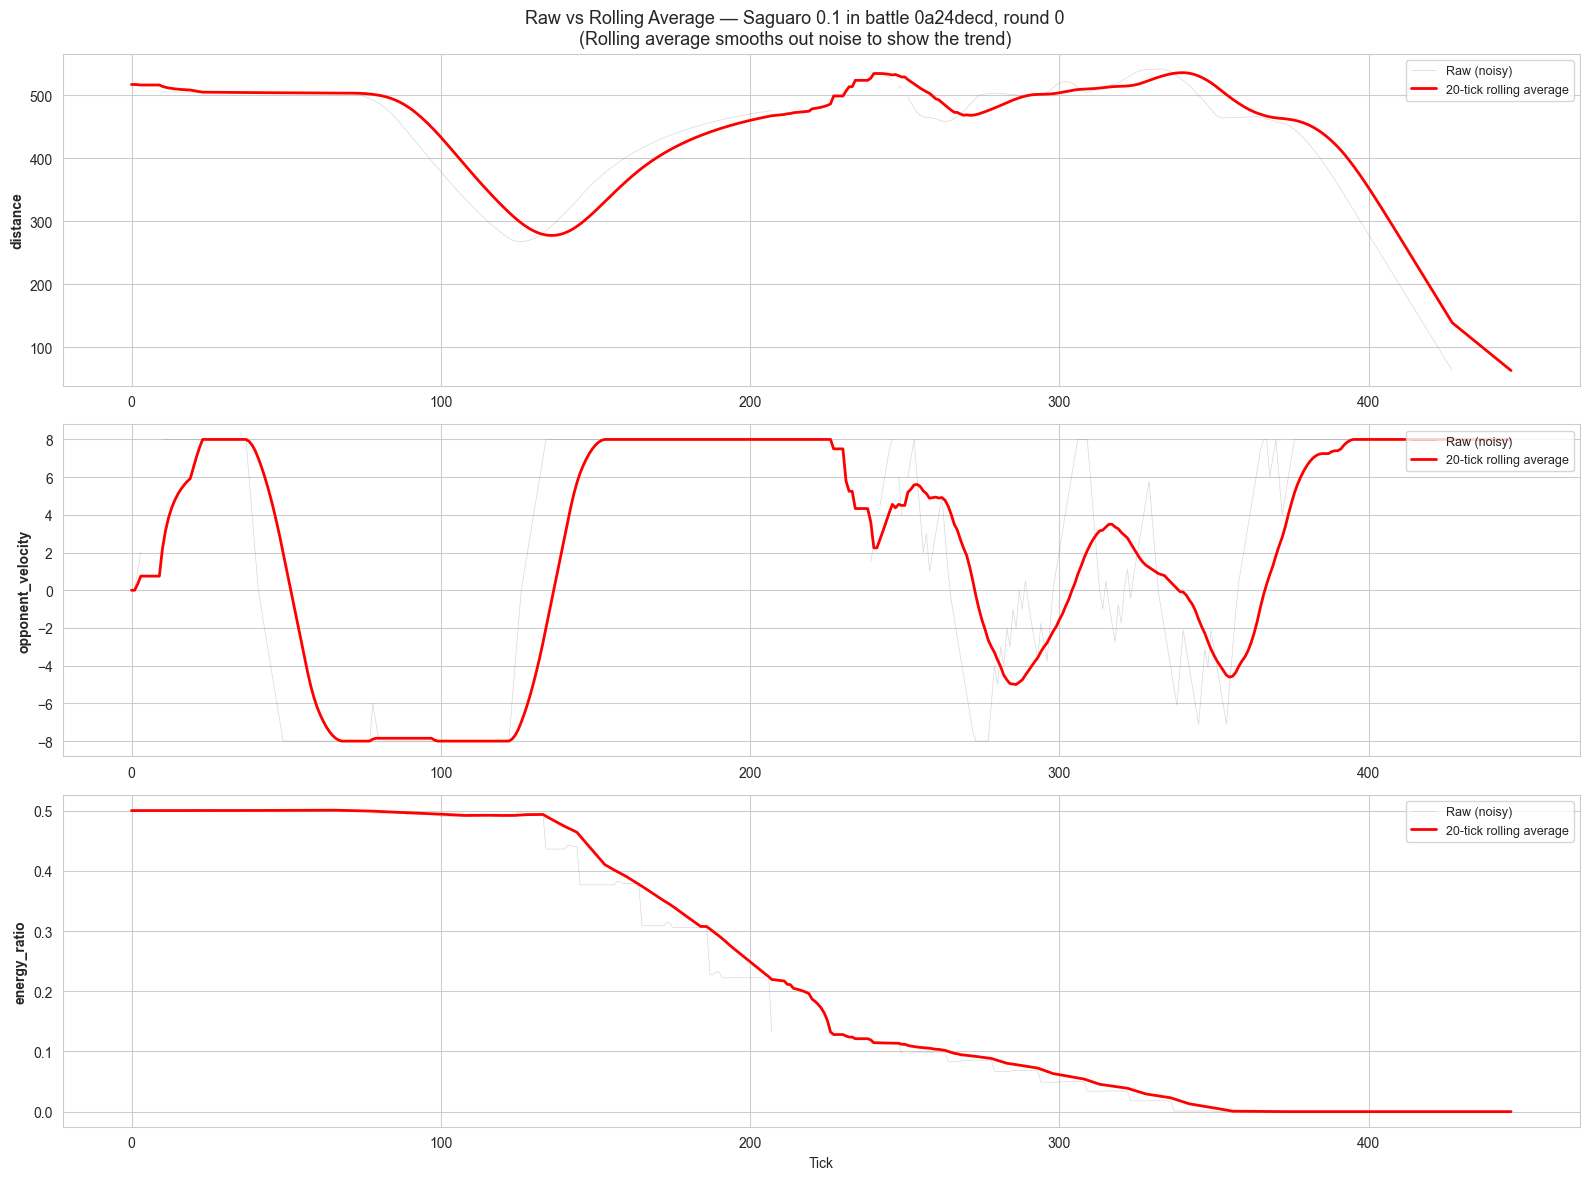

In [8]:
# --- Rolling averages for one round ---
# Pick first battle, first round, first robot
first_battle = ticks['battle_id'].unique()[0]
first_robot = ticks[ticks['battle_id'] == first_battle]['robot_name'].unique()[0]
round_data = ticks[(ticks['battle_id'] == first_battle) & 
                    (ticks['round'] == 0) & 
                    (ticks['robot_name'] == first_robot)].copy()

rolling_features = ['distance', 'opponent_velocity', 'energy_ratio']
rolling_features = [f for f in rolling_features if f in round_data.columns]

fig, axes = plt.subplots(len(rolling_features), 1, figsize=(16, 4 * len(rolling_features)))
if len(rolling_features) == 1:
    axes = [axes]

window = 20  # 20-tick rolling average

for ax, feat in zip(axes, rolling_features):
    raw = round_data[feat]
    smoothed = raw.rolling(window=window, min_periods=1).mean()
    
    ax.plot(round_data['tick'], raw, alpha=0.3, linewidth=0.5, label='Raw (noisy)', color='gray')
    ax.plot(round_data['tick'], smoothed, linewidth=2, label=f'{window}-tick rolling average', color='red')
    ax.set_ylabel(feat, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel("Tick")
fig.suptitle(f"Raw vs Rolling Average — {first_robot} in battle {first_battle}, round 0\n"
             f"(Rolling average smooths out noise to show the trend)", fontsize=13)
plt.tight_layout()
plt.show()

## Cross-Battle Comparison: Per-Robot Aggregates

How do different robots compare across all battles? Are some consistently better? Do they behave differently depending on the opponent?

Per-Robot Aggregate Statistics (across all battles):


damage_dealt         damage_received          \
                                    mean     std            mean     std   
robot_name                                                                 
BeepBoop 2.0                      35.876  16.060          19.754  10.350   
Diamond 1.8.22                    33.038  21.454          23.412  16.332   
DrussGT 3.1.7                     24.040  14.270          43.119  25.207   
Saguaro 0.1                       27.398  26.206          44.188  21.250   
ScalarR 0.005h.053-noshield       37.001  22.367          26.879  15.189   

                            net_damage our_hit_rate opponent_hit_rate  \
                                  mean         mean              mean   
robot_name                                                              
BeepBoop 2.0                    16.122        0.116             0.091   
Diamond 1.8.22                   9.625        0.094             0.079   
DrussGT 3.1.7                  -19.079        0.100             0.119   
Saguaro 0.1                    -16.790        0.059             0.219   
ScalarR 0.005h.053-noshield     10.122        0.134             0.104   

                            ticks_in_round  
                                      mean  
robot_name                                  
BeepBoop 2.0                       3931.15  
Diamond 1.8.22                     2412.60  
DrussGT 3.1.7                      2919.75  
Saguaro 0.1                         767.45  
ScalarR 0.005h.053-noshield        3313.55

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_82724\2652997304.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=scores, x='robot_name', y='net_damage', ax=axes[0], palette='Set2')
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_82724\2652997304.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_82724\2652997304.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=scores, x='robot_name', y='our_hit_rate', ax=axes[1], palette='Set2')
C:\Users\pav

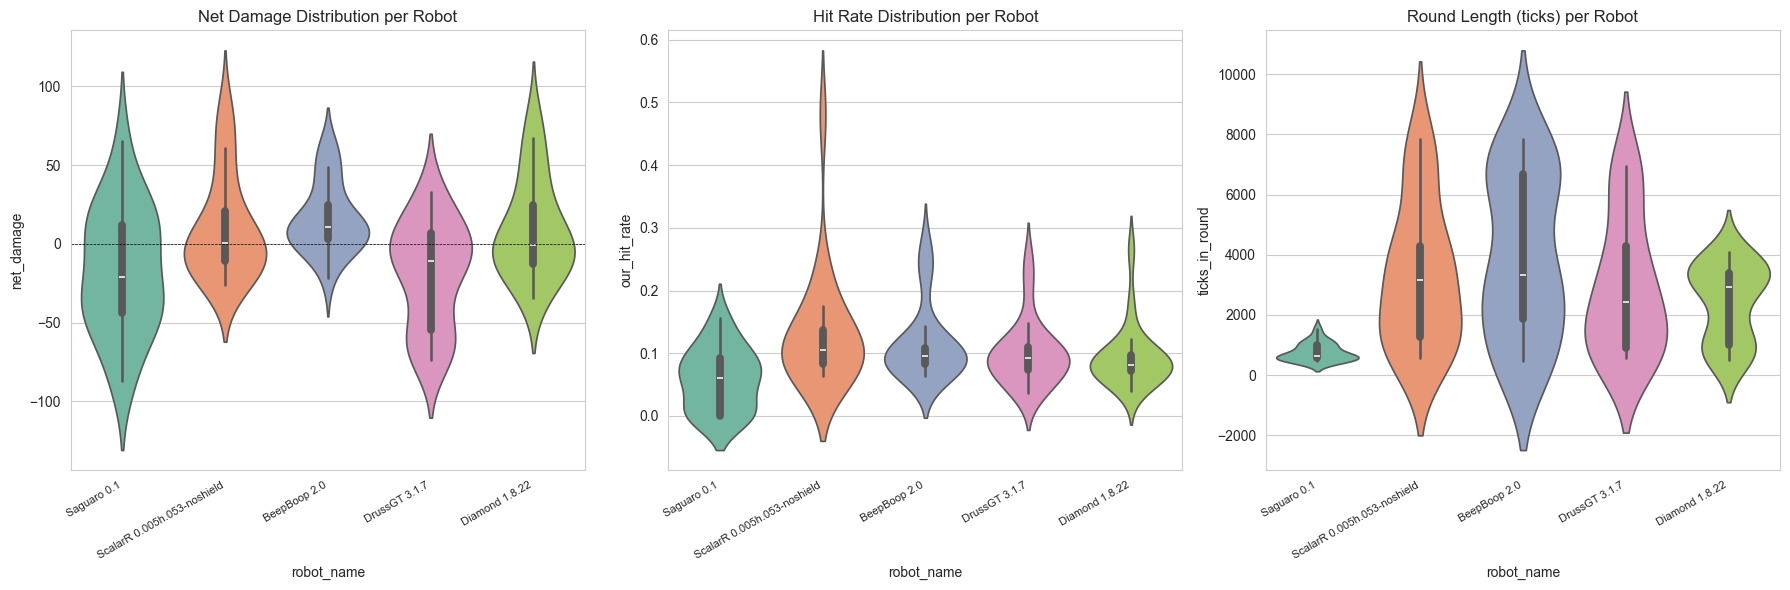

In [9]:
# --- Per-robot aggregate stats ---
robot_stats = scores.groupby('robot_name').agg({
    'damage_dealt': ['mean', 'std'],
    'damage_received': ['mean', 'std'],
    'net_damage': 'mean',
    'our_hit_rate': 'mean',
    'opponent_hit_rate': 'mean',
    'ticks_in_round': 'mean',
}).round(3)

print("Per-Robot Aggregate Statistics (across all battles):")
display(robot_stats)

# Violin plots for key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.violinplot(data=scores, x='robot_name', y='net_damage', ax=axes[0], palette='Set2')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[0].set_title("Net Damage Distribution per Robot")
axes[0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')

if 'our_hit_rate' in scores.columns:
    sns.violinplot(data=scores, x='robot_name', y='our_hit_rate', ax=axes[1], palette='Set2')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
    axes[1].set_title("Hit Rate Distribution per Robot")

sns.violinplot(data=scores, x='robot_name', y='ticks_in_round', ax=axes[2], palette='Set2')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[2].set_title("Round Length (ticks) per Robot")

plt.tight_layout()
plt.show()

## Summary

Run this cell to save a summary of key findings.

In [10]:
# --- Save summary ---
summary = f"""# Intuition Phase — Key Findings

## Dataset
- {len(ticks):,} tick rows, {len(feature_cols)} predictor features
- 5 robots: {', '.join(sorted(ticks['robot_name'].unique()))}

## ML Baselines
- **Fire prediction task:** {best_name}
  - Test accuracy: {results[best_name]['test_accuracy']:.4f}
  - Train accuracy: {results[best_name]['train_accuracy']:.4f}

## Top 5 Features for Fire Prediction
"""
for feat, imp in importances.nlargest(5).items():
    summary += f"- {feat}: {imp:.4f}\n"

summary += f"""
## Next Steps
- Investigate top features in more depth
- Add more recordings for more training data
- Explore sequence-based models (LSTM, etc.) for time-series patterns
- Build features specifically designed for the top predictors
"""

summary_path = Path("findings_summary.md")
summary_path.write_text(summary)
print(f"Summary saved to {summary_path.resolve()}")
print(summary)

Summary saved to D:\robocode-autopilot\intuition\findings_summary.md
# Intuition Phase — Key Findings

## Dataset
- 266,890 tick rows, 22 predictor features
- 5 robots: BeepBoop 2.0, Diamond 1.8.22, DrussGT 3.1.7, Saguaro 0.1, ScalarR 0.005h.053-noshield

## ML Baselines
- **Fire prediction task:** Random Forest (100 trees)
  - Test accuracy: 0.9888
  - Train accuracy: 0.9915

## Top 5 Features for Fire Prediction
- opponent_inferred_gun_heat: 0.8845
- opponent_energy: 0.0326
- our_gun_heat: 0.0203
- distance_norm: 0.0100
- energy_ratio: 0.0089

## Next Steps
- Investigate top features in more depth
- Add more recordings for more training data
- Explore sequence-based models (LSTM, etc.) for time-series patterns
- Build features specifically designed for the top predictors

